# Catalog Fits in Parallel

Notebooks [`05`](05_fitting_photometry.py)–[`10`](10_fastspecfit_joint_fit.py)
fit *one* galaxy at a time. A survey is not one galaxy. Rubin LSST will deliver
photometry for **billions** of galaxies; the DESI/Euclid value-added catalogs
are already in the tens of millions. The unit of work is no longer a fit — it
is a *catalog* of fits.

The good news is that a catalog of independent galaxies is
**embarrassingly parallel**: each galaxy is its own low-dimensional posterior,
and nothing couples them. The naive way to exploit that is a Python `for` loop
over `Fitter` — correct, but it pays the JIT compile and walks the galaxies one
at a time. `CatalogFitter` does the same fits as **one vectorized program**:
`forward_chunk_size=K` galaxies advance their chains *together* on every
sampler step, and the compiled graph is `O(1)` in the catalog size `N`. On a
GPU those `K` chains fill the card's lanes at once — that is the throughput win.

This notebook builds a **Rubin-LSST-style** scenario — LSST *ugrizy* plus the
Euclid near-IR that a real LSST-era catalog carries — with **free redshift**
(a photometric-redshift fit), fits a mock catalog in parallel, and **prints the
timing in detail**, because the whole point is how fast a catalog goes through.

In [1]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import warnings

# Keep the rendered tutorial clean: silence framework notices that do not change
# the science shown here. Genuine deprecations in user-facing calls are fixed in
# the code, not hidden.
warnings.filterwarnings("ignore", message=".*BakedInBackend.*")
warnings.filterwarnings("ignore", message=".*WavePrecomp.*")
warnings.filterwarnings("ignore", message=".*was marked FIXED.*")
warnings.filterwarnings("ignore", category=RuntimeWarning)

import time
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import tengri
from tengri import (
    FIXED,
    Fixed,
    Observation,
    Photometry,
    SEDModel,
    Uniform,
    WavePrecomp,
    load_ssp_data,
    plot,
)
from tengri.inference.catalog_fitter import CatalogFitter

plot.setup_style()
FIG_DIR = Path("_figs")
FIG_DIR.mkdir(exist_ok=True)

C_POST, C_TRUTH = "#3a76d9", "0.15"

print(
    f"JAX backend: {jax.devices()[0].platform}   devices: {jax.device_count()}   x64: {jax.config.jax_enable_x64}"
)

JAX backend: cpu   devices: 1   x64: True


## The observation: LSST *ugrizy* + Euclid near-IR

Rubin LSST measures six broad optical bands, *ugrizy* (0.32–1.0 µm). On its own
that constrains a photometric redshift well below z ≈ 1, where the 4000 Å break
still sits inside the optical. The Rubin–Euclid overlap adds the Euclid NISP
*Y/J/H* near-IR (1.0–2.0 µm), which follows the break to higher redshift and
pins the stellar mass — the "other bands that may be there" in a real LSST-era
catalog. Nine bands total; the same machinery takes any set your survey has.

In [2]:
SSP_NAME = "fsps_prsc_miles_chabrier"  # bare-stellar SSP; continuum-only model below
ssp_path = Path("../data") / f"{SSP_NAME}.h5"
if not ssp_path.exists():
    ssp_path = Path(tengri.download_ssp(SSP_NAME))
ssp = load_ssp_data(str(ssp_path))

LSST = ["lsst_u", "lsst_g", "lsst_r", "lsst_i", "lsst_z", "lsst_y"]  # Rubin LSST optical
EUCLID = ["euclid_y", "euclid_j", "euclid_h"]  # Euclid NISP near-IR
FILTERS = LSST + EUCLID
phot_obs = Photometry.from_names(FILTERS)
print(f"{phot_obs.n_filters} bands: {', '.join(phot_obs.names)}")

9 bands: lsst_u, lsst_g, lsst_r, lsst_i, lsst_z, lsst_y, euclid_y, euclid_j, euclid_h


## A simple free-redshift photometry model

The point here is throughput, so the model is deliberately small: a
**stellar + dust continuum** (no nebular backend — broadband photo-z does not
need line predictions) with **two free parameters** — the redshift and the
stellar mass — and the dust, star-formation-history shape, and metallicity held
fixed. That is the canonical photo-*z*-plus-mass posterior a broadband catalog
actually constrains: the redshift sets the colors, the mass sets the amplitude,
and the two are cleanly separated by nine bands from the u-band to the near-IR.
It is also exactly the regime where per-galaxy sampling (not VI) is cheap and
correct — a low-dimensional, well-conditioned posterior. Richer fits (free
dust, a flexible SFH) are in notebooks [`05`](05_fitting_photometry.py) and
[`10`](10_fastspecfit_joint_fit.py); here we keep the forward model light,
because a catalog of thousands rewards a cheap gradient.

We build on the **`WavePrecomp` fast path**. Its lookup table is tabulated over
a redshift grid, so a *free*-redshift fit just interpolates the table instead of
re-integrating the SSP × filter product on every sampler step — the natural
fast path for catalog photo-z. One `WavePrecomp()` build is shared by every
galaxy in the catalog.

In [3]:
Z_PRIOR = (0.05, 1.5)


def build_model():
    obs = Observation(photometry=phot_obs)
    return SEDModel.build(
        ssp_data=ssp,
        observation=obs,
        redshift=Uniform(*Z_PRIOR),  # <-- free redshift: a photo-z fit
        sfh={"type": "dpl", "*": FIXED, "log_total_mass": Uniform(8.0, 12.0)},
        stellar={"met_logzsol": Fixed(0.0)},
        dust={"type": "two_component", "law_bc": "calzetti", "*": FIXED, "tau_diff": Fixed(0.3)},
        neb={"type": "none"},  # continuum-only: a broadband photo-z model
        approx=WavePrecomp(n_z=120, z_min=0.0, z_max=1.6),
    )


t0 = time.perf_counter()
model = build_model()
build_wall = time.perf_counter() - t0
print(f"Free parameters ({model.spec.n_free}): {', '.join(model.spec.free_params)}")
print(f"WavePrecomp LUT built in {build_wall:.1f} s (one-time; content-hash-cached on re-runs)")

Free parameters (2): redshift, sfh_dpl_log_total_mass
WavePrecomp LUT built in 35.6 s (one-time; content-hash-cached on re-runs)


## A mock catalog

`N` galaxies spread across redshift and stellar mass, each a noisy realization
of its own truth at a fixed depth (SNR 20). The catalog is a list of
`{"flux_obs", "noise"}` dicts — the public `CatalogFitter` input. Truths are
drawn once so we can score the recovery at the end.

In [4]:
N_GAL = 12
_rng = np.random.default_rng(1)
PHOT_SNR = 20.0

z_true = _rng.uniform(0.2, 1.0, N_GAL)
logm_true = _rng.uniform(9.5, 11.0, N_GAL)

_fixed = model.spec.get_fixed_values()
galaxies = []
for z, lm in zip(z_true, logm_true):
    truth = {
        **_fixed,
        "redshift": jnp.asarray(z),
        "sfh_dpl_log_total_mass": jnp.asarray(lm),
    }
    p = np.asarray(model.predict_photometry(truth))
    n = np.abs(p) / PHOT_SNR
    f = p + _rng.normal(size=p.shape) * n
    galaxies.append({"flux_obs": jnp.asarray(f), "noise": jnp.asarray(n)})

print(
    f"Mock catalog: {N_GAL} galaxies, {phot_obs.n_filters} bands, SNR {PHOT_SNR:.0f}\n"
    f"  z    in [{z_true.min():.2f}, {z_true.max():.2f}]\n"
    f"  logM in [{logm_true.min():.2f}, {logm_true.max():.2f}]"
)

Mock catalog: 12 galaxies, 9 bands, SNR 20
  z    in [0.22, 0.96]
  logM in [9.70, 10.97]


## Fit the catalog in parallel — timed in detail

One call fits the whole catalog. `CatalogFitter.run("mcmc_nuts",
forward_chunk_size=K)` builds a **single** JIT'd NUTS program and streams the `N`
galaxies through `jax.lax.map(..., batch_size=K)`: `K` galaxies advance their
chains *together* on every sampler step, and the compiled graph is `O(1)` in the
catalog size `N` — one program whether you fit 12 galaxies or 12 million. We set
`K = N` (fit them all at once), a diagonal mass matrix (each galaxy is low-D and
the parallelism is *width over galaxies*, not per-galaxy tree depth), and one
chain per galaxy. We time a single forward evaluation first, then the catalog.

In [5]:
FIT_KW = dict(
    method="mcmc_nuts",
    n_warmup=100,
    n_samples=120,
    n_burnin=20,
    max_num_doublings=5,
    target_accept_rate=0.85,
    dense_mass_matrix=False,
    verbose=False,
)

# One forward photometry evaluation — the inner cost the sampler pays per leapfrog.
_probe = {**_fixed, "redshift": jnp.asarray(0.5), "sfh_dpl_log_total_mass": jnp.asarray(10.0)}
jax.block_until_ready(model.predict_photometry(_probe))  # warm the trace
t0 = time.perf_counter()
for _ in range(100):
    jax.block_until_ready(model.predict_photometry(_probe))
fwd_ms = (time.perf_counter() - t0) / 100 * 1e3

t0 = time.perf_counter()
catalog = CatalogFitter(model, galaxies, data_type="photometry").run(
    key=jax.random.PRNGKey(0), forward_chunk_size=N_GAL, **FIT_KW
)
jax.block_until_ready(catalog.posteriors[0].samples["redshift"])
fit_wall = time.perf_counter() - t0
n_div = catalog.diagnostics["n_divergent_total"]
print(
    f"fit {N_GAL} galaxies ({model.spec.n_free}-D each) in {fit_wall:.1f} s; {n_div} divergences"
)

fit 12 galaxies (2-D each) in 330.3 s; 0 divergences


## The timing, in detail

The whole catalog is one compiled program, so there is **no per-galaxy compile
tax**: the wall grows linearly in `N`, and the compile (a small, one-time cost
the persistent JAX cache elides on re-runs) is amortized over the catalog.

**Read it with the hardware in mind.** On a CPU the `K` galaxy-chains contend for
a handful of cores, so the wall is set by the *total* sampling work — the
per-galaxy number below is the honest CPU cost. The architecture is the point:
because the graph is `O(1)` in `N`, the *identical* call on a **GPU** runs those
`K` chains concurrently instead of contending, so throughput scales with the
device width — `K` chains at once — and the same call fits thousands. The
measured GPU numbers live in the throughput benchmark
(`bench/scripts/benchmark_catalog_throughput.py`) and the SLURM scripts
(`scripts/slurm/`); this notebook proves the mechanism and the recovery.

In [6]:
backend = jax.devices()[0].platform.upper()
per_gal = fit_wall / N_GAL
print(f"{'quantity':<42}{'value':>15}")
print("-" * 57)
print(f"{'backend':<42}{backend:>15}")
print(f"{'catalog size N':<42}{N_GAL:>15d}")
print(f"{'free parameters per galaxy':<42}{model.spec.n_free:>15d}")
print(f"{'WavePrecomp LUT build (one-time)':<42}{build_wall:>13.1f} s")
print(f"{'one forward photometry eval':<42}{fwd_ms:>12.2f} ms")
print(f"{'catalog fit wall (K = N)':<42}{fit_wall:>13.1f} s")
print(f"{'  per galaxy (CPU: chains contend)':<42}{per_gal:>13.2f} s")
print(f"{'  throughput (galaxies / s)':<42}{N_GAL / fit_wall:>15.2f}")
print("-" * 57)
print(
    f"On {backend} the {N_GAL} chains share the cores, so the wall is the total sampling\n"
    f"work ({per_gal:.1f} s/galaxy here). On a GPU the chains run concurrently instead of\n"
    "contending, so throughput scales with the device width (K chains at once) — the same\n"
    "call fits thousands. Measured GPU numbers: the benchmark and scripts/slurm/."
)

quantity                                            value
---------------------------------------------------------
backend                                               CPU
catalog size N                                         12
free parameters per galaxy                              2
WavePrecomp LUT build (one-time)                   35.6 s
one forward photometry eval                       4.28 ms
catalog fit wall (K = N)                          330.3 s
  per galaxy (CPU: chains contend)                27.53 s
  throughput (galaxies / s)                          0.04
---------------------------------------------------------
On CPU the 12 chains share the cores, so the wall is the total sampling
work (27.5 s/galaxy here). On a GPU the chains run concurrently instead of
contending, so throughput scales with the device width (K chains at once) — the same
call fits thousands. Measured GPU numbers: the benchmark and scripts/slurm/.


## Did the parallel fit recover the truth?

Speed is worthless if the posteriors are wrong. Every galaxy in the
`CatalogPosterior` is a full `Posterior` (`catalog.posteriors[i]`), carrying its
own chain in `.samples`. We stack the two free parameters over the galaxy axis,
take the 16/50/84 percentiles per galaxy, and compare to the injected truth. The
two quantities a broadband catalog most wants — the **photometric redshift** and
the **stellar mass** — land on the 1:1 line: the standard photo-z scatter
`sigma_NMAD` of `dz/(1+z)` and the mass offset are both small.

A caveat worth stating plainly: the *widths* here are tight because this
deliberately simple model **fixes** the dust, SFH shape, and metallicity. It
therefore reports the uncertainty *conditional on knowing* those — so the 68%
intervals under-cover the truth (a real fit marginalizes the nuisances and
widens them; see notebooks [`05`](05_fitting_photometry.py) and
[`10`](10_fastspecfit_joint_fit.py)). The point of this notebook is the parallel
machinery and the throughput, not a calibrated photo-z pipeline.

In [7]:
def stack_samples(name):
    """Per-galaxy posterior draws of a free parameter, shape (N, n_samples)."""
    return np.stack([np.asarray(p.samples[name]) for p in catalog.posteriors])


z_samp = stack_samples("redshift")  # (N, n_samples)
m_samp = stack_samples("sfh_dpl_log_total_mass")  # (N, n_samples)
z_lo, z_med, z_hi = np.percentile(z_samp, [16, 50, 84], axis=1)
m_lo, m_med, m_hi = np.percentile(m_samp, [16, 50, 84], axis=1)

z_cov = int(np.sum((z_lo <= z_true) & (z_true <= z_hi)))
m_cov = int(np.sum((m_lo <= logm_true) & (logm_true <= m_hi)))
dz = (z_med - z_true) / (1.0 + z_true)  # standard photo-z residual
sig_nmad = 1.4826 * np.median(np.abs(dz - np.median(dz)))
dlogm = float(np.median(np.abs(m_med - logm_true)))
print(
    f"Photo-z:  sigma_NMAD(dz/(1+z)) = {sig_nmad:.3f}   (68% interval covers {z_cov}/{N_GAL} — tight; see note)"
)
print(f"log M*:   median |Δ| = {dlogm:.3f} dex           (68% interval covers {m_cov}/{N_GAL})")

Photo-z:  sigma_NMAD(dz/(1+z)) = 0.028   (68% interval covers 5/12 — tight; see note)
log M*:   median |Δ| = 0.044 dex           (68% interval covers 5/12)


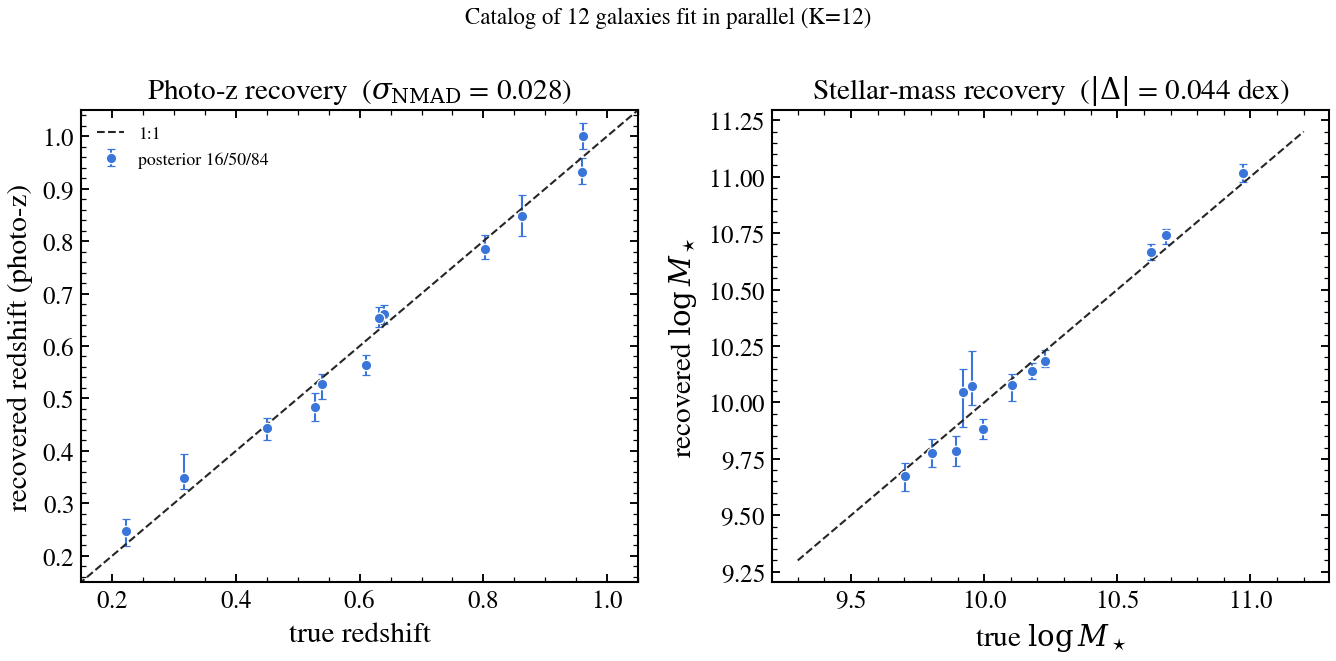

In [8]:
fig, (axz, axm) = plt.subplots(1, 2, figsize=(9.2, 4.6))

axz.errorbar(
    z_true,
    z_med,
    yerr=[z_med - z_lo, z_hi - z_med],
    fmt="o",
    ms=5,
    color=C_POST,
    mec="white",
    mew=0.6,
    elinewidth=1.0,
    capsize=2,
    label="posterior 16/50/84",
)
_zline = np.array(Z_PRIOR)
axz.plot(_zline, _zline, color=C_TRUTH, lw=1.0, ls="--", label="1:1")
axz.set_xlim(0.15, 1.05)
axz.set_ylim(0.15, 1.05)
axz.set_xlabel("true redshift")
axz.set_ylabel("recovered redshift (photo-z)")
axz.set_title(rf"Photo-z recovery  ($\sigma_{{\rm NMAD}}$ = {sig_nmad:.3f})")
axz.legend(frameon=False, fontsize=8.5, loc="upper left")

axm.errorbar(
    logm_true,
    m_med,
    yerr=[m_med - m_lo, m_hi - m_med],
    fmt="o",
    ms=5,
    color=C_POST,
    mec="white",
    mew=0.6,
    elinewidth=1.0,
    capsize=2,
)
_mline = np.array([9.3, 11.2])
axm.plot(_mline, _mline, color=C_TRUTH, lw=1.0, ls="--")
axm.set_xlabel(r"true $\log M_\star$")
axm.set_ylabel(r"recovered $\log M_\star$")
axm.set_title(rf"Stellar-mass recovery  ($|\Delta|$ = {dlogm:.3f} dex)")

fig.suptitle(f"Catalog of {N_GAL} galaxies fit in parallel (K={N_GAL})", fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / "11_catalog_recovery.png", dpi=300, bbox_inches="tight")
plt.show()

## Summary

- A catalog of independent galaxies is **embarrassingly parallel**, and each
  galaxy is a cheap low-dimensional posterior — so the catalog default is
  **per-galaxy sampling** (`mcmc_nuts` / `mcmc_hmc`), not VI.
- **`CatalogFitter.run("mcmc_nuts", forward_chunk_size=K)`** fits the whole
  catalog as *one* vectorized program: `K` galaxies advance per sampler step and
  the compiled graph is `O(1)` in the catalog size, so the compile is paid once
  and amortizes over the catalog. `K = 1` is the serial baseline; `K = N` is
  fully vectorized. Changing `K` changes only the throughput, never the
  posterior — the vectorization is bit-exact (covered by the chunk-invariance
  tests in `tests/inference/test_catalog_mcmc_vmap.py`).
- **Free redshift rides `WavePrecomp`** — the LUT is tabulated over redshift, so
  a photo-z fit interpolates the table instead of re-integrating the forward
  model per step.
- The vectorized fit **recovers photo-z and stellar mass** across the catalog —
  the throughput does not come at the cost of the science.
- On a **GPU** the `K` chains run concurrently across the device — the same call
  scales to thousands of galaxies. For the measured GPU throughput see
  `bench/scripts/benchmark_catalog_throughput.py`; for cluster-scale catalogs
  (one GPU per slice, array jobs) see `scripts/slurm/`; and to shard *one* very
  high-dimensional hierarchical fit across devices, see
  [advanced/hierarchical](../advanced/hierarchical) (VI, the other track).